In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../")
from src.preprocessing import weigh_norm_densities, align_densities, df_to_densities
from src.transformations import ( 
                            mLQDT,
                            obtain_densities_from_lqd
                            )

import plotly.graph_objects as go
import plotly.express as px

In [2]:
# Dados
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")
df.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:00:00,0.000011,-0.000372,-0.000035,0.007233,-0.001305,-0.000459,0.002388,0.002212,-0.008001,-0.000824,...,-0.000957,-0.002307,-0.003734,-0.005020,-0.001139,-0.000255,0.002339,0.004176,-0.000224,-0.000238
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004


<Axes: >

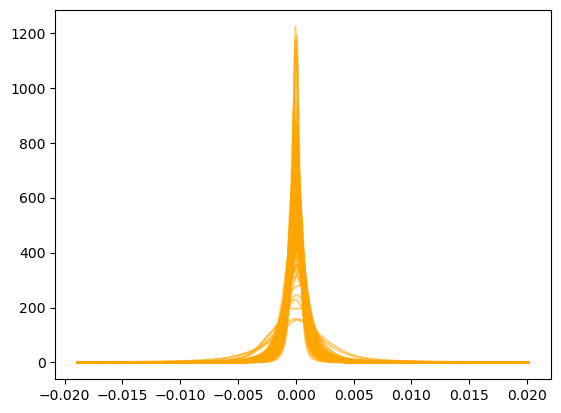

In [28]:
params = {"kernel": "t_student", "bandwidth": "scott", "df": 2, "adaptive": True}

df_support, df_densities = df_to_densities(df, params, verbose=False)

df_densities.plot(legend=False, alpha=.5, color="orange")

In [ ]:
bovespa_mLQDT = mLQDT(
                    df_densities.reset_index(drop=True),
                    df_support.reset_index(drop=True)
                )
bovespa_mLQDT.densities_to_lqdensities(verbose=False)

df_lqds = bovespa_mLQDT.lqd.iloc[1:-1,:]
df_lqds_support = bovespa_mLQDT.lqd_support[1:-1]

In [37]:
fig = px.line(
    df_lqds,
    color_discrete_sequence=["#1f77b4"]
)

fig.update_traces(
    opacity=0.25,          # alpha
    line=dict(width=1)    # thin lines
)

fig.update_layout(
    legend=dict(
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top"
    ),
    margin=dict(r=160),  # make room for the legend
    title=f"{params}"
)

fig.show()

In [16]:
kle_bkw_supports, kle_bkw_densities = obtain_densities_from_lqd(
                                                            df_lqds,
                                                            bovespa_mLQDT.lqd_support,
                                                            bovespa_mLQDT.c,
                                                            verbose=False
                                                            )

df_supp, df_density_observed, df_density_estimated = align_densities(
                                                        df_support, 
                                                        df_densities, 
                                                        kle_bkw_supports, 
                                                        kle_bkw_densities, 
                                                        kle_bkw_densities.columns)

In [ ]:
# Visualização
i = 10
t = df.columns[i]

fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_supp.loc[:,t],
        y=df_density_observed.loc[:,t],
        mode="lines",
        name="Gaussian KDE | silverman",
        line=dict(color="black")
    )
)

# t-kernel KDE df = 4
fig.add_trace(
    go.Scatter(
        x=df_supp.loc[:,t],
        y=df_density_estimated.loc[:,t],
        mode="lines",
        name="t-kernel KDE | df = 3 | silverman",
        line=dict(color="green")
    )
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor="rgba(0,0,0,0.2)")
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor="rgba(0,0,0,0.2)")

fig.update_layout(
    legend=dict(
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top"
    ),
    margin=dict(r=160),  # make room for the legend
    title=f"{params}"
)

fig.show()